# Advanced EDA and Feature Selection

This notebook reviews the customer-level feature table with business-oriented visuals, then selects a simple first-baseline feature set for clustering. It does not run clustering, fit models, or create association rules.

## Imports and Data Loading

Use the interpretable feature table for EDA visuals and the preprocessed model table for feature selection.

In [1]:
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sys.path.append("../src")
from features import create_basket_features

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "axes.titlesize": 14,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "grid.color": "#E5E7EB",
        "grid.linewidth": 0.8,
    }
)

PRIMARY = "#356D8C"
SECONDARY = "#5C8A72"
ACCENT = "#C9822B"
DANGER = "#B4514E"
MUTED = "#8892A0"
CATEGORY_PALETTE = [
    "#356D8C",
    "#5C8A72",
    "#C9822B",
    "#7C6FA4",
    "#B4514E",
    "#4F8F8B",
    "#8C6D46",
    "#6B7A90",
    "#9A6B7E",
    "#708C52",
]


def display_figure():
    plt.tight_layout()
    plt.show()


def clean_label(value):
    return value.replace("share_", "").replace("_", " ").title()


In [2]:
customer_features_info = pd.read_csv("../data/processed/customer_features_info.csv")
selected_model_features = pd.read_csv("../data/processed/selected_model_features.csv")
customer_basket = pd.read_csv("../data/raw/customer_basket.csv")

basket_features = create_basket_features(customer_basket)
customer_features = customer_features_info.merge(basket_features, on="customer_id", how="left")

basket_numeric_features = [
    "basket_count",
    "avg_basket_size",
    "max_basket_size",
    "min_basket_size",
    "total_items_bought_in_baskets",
    "distinct_products_in_baskets",
    "avg_distinct_products_per_basket",
]
customer_features[basket_numeric_features] = customer_features[basket_numeric_features].fillna(0)
customer_features["most_frequent_product"] = customer_features["most_frequent_product"].fillna("No Basket")

print(f"customer_features_info shape: {customer_features_info.shape}")
print(f"selected_model_features shape: {selected_model_features.shape}")
print(f"customer_features for EDA shape: {customer_features.shape}")


customer_features shape: (33038, 37)
customer_features_model shape: (33038, 40)


In [3]:
customer_features.head()

   customer_id customer_gender  kids_home  teens_home  number_complaints  distinct_stores_visited  lifetime_total_distinct_products  year_first_transaction  percentage_of_products_bought_promotion  typical_hour   latitude  longitude   age  customer_tenure  has_loyalty_card  total_children_home  has_children  total_lifetime_spend  share_groceries  share_electronics  share_vegetables  share_nonalcohol_drinks  share_alcohol_drinks  share_meat  share_fish  share_hygiene  share_videogames  share_petfood degree_level  basket_count  avg_basket_size  max_basket_size  min_basket_size  total_items_bought_in_baskets  distinct_products_in_baskets  avg_distinct_products_per_basket most_frequent_product
0            3          female        1.0         1.0                1.0                      3.0                             189.0                  2020.0                                 0.631599           NaN  38.794428  -9.215739  59.0              9.0                 1                  2.0       

## Customer Value

The first check is whether customer value has a strong skew or high-value tail. This matters because clustering algorithms are distance-based: even after scaling, a few extreme customers can influence the shape of the segmentation.

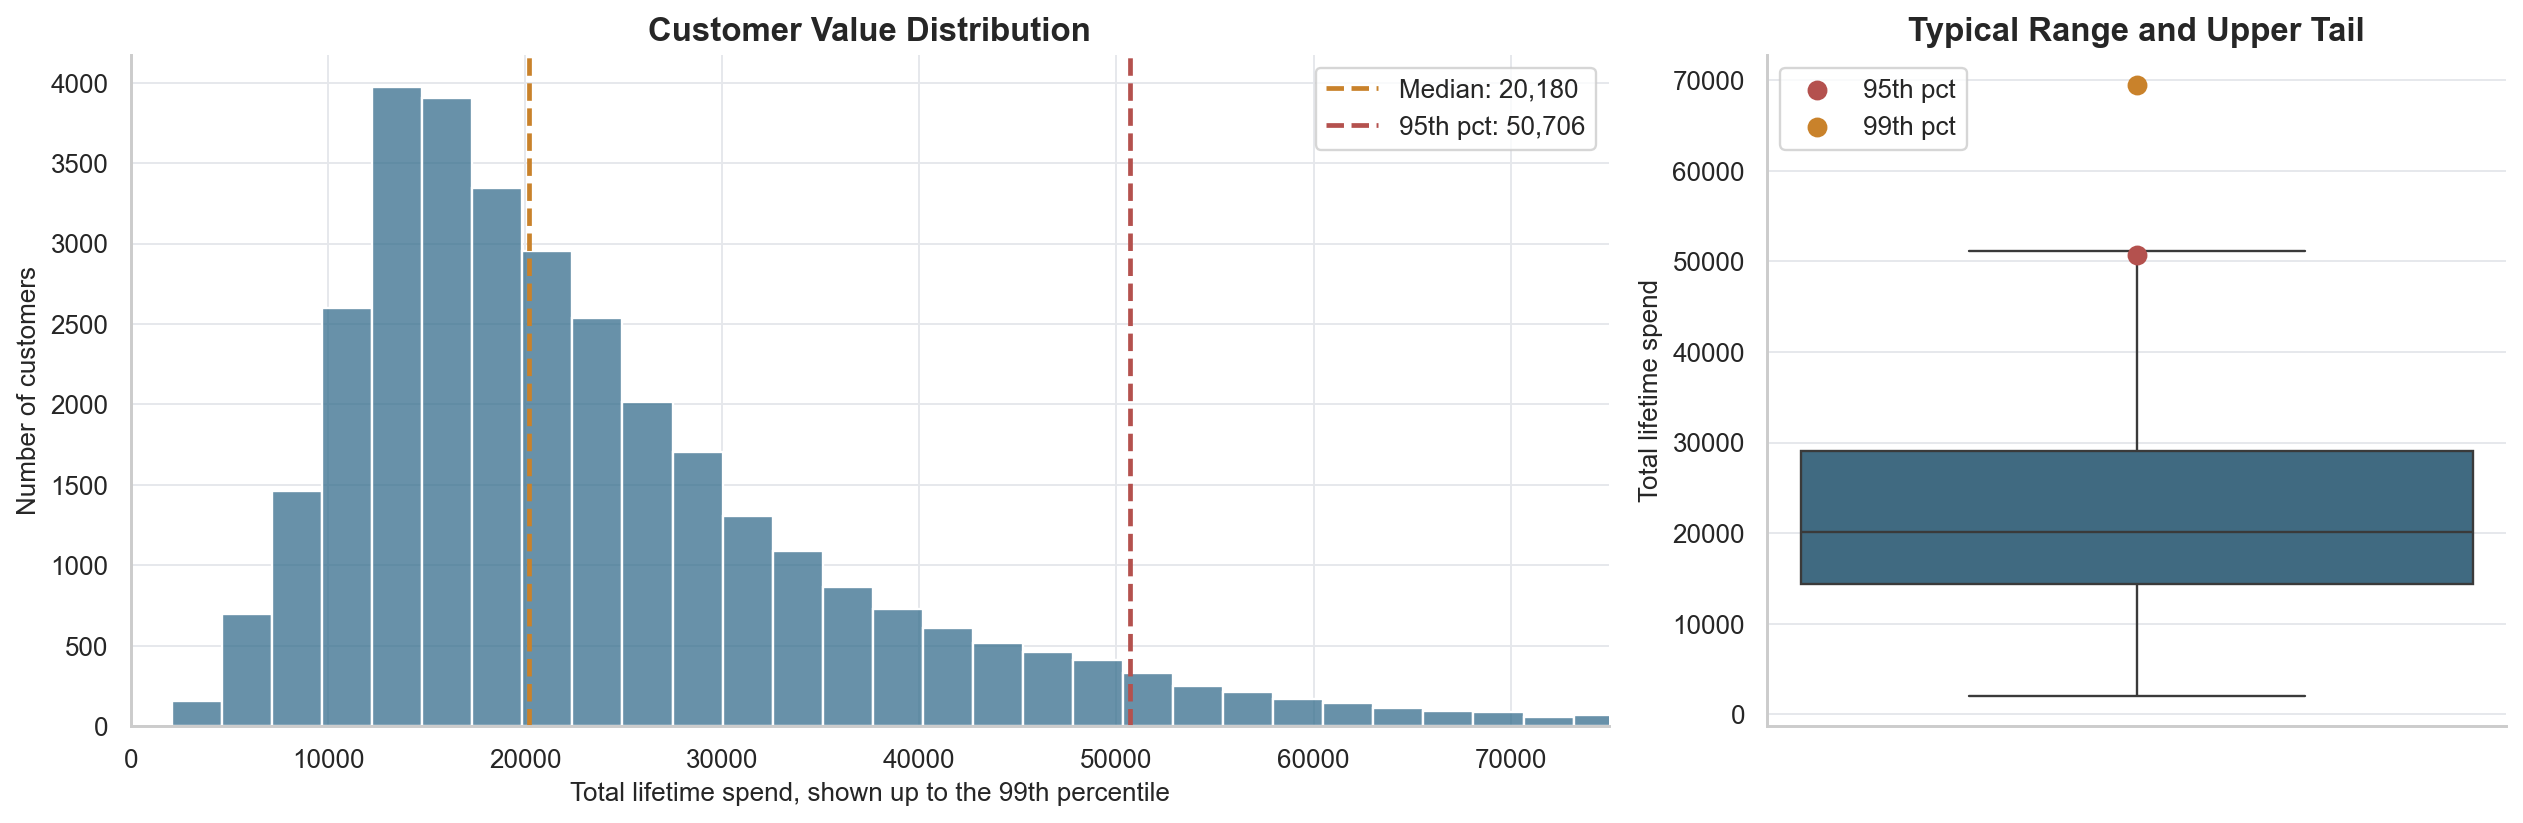

In [4]:
spend_median = customer_features["total_lifetime_spend"].median()
spend_p95 = customer_features["total_lifetime_spend"].quantile(0.95)
spend_p99 = customer_features["total_lifetime_spend"].quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [2, 1]})

sns.histplot(customer_features["total_lifetime_spend"], bins=45, color=PRIMARY, edgecolor="white", ax=axes[0])
axes[0].axvline(spend_median, color=ACCENT, linestyle="--", linewidth=2, label=f"Median: {spend_median:,.0f}")
axes[0].axvline(spend_p95, color=DANGER, linestyle="--", linewidth=2, label=f"95th pct: {spend_p95:,.0f}")
axes[0].set_xlim(0, spend_p99 * 1.08)
axes[0].set_title("Customer Value Distribution")
axes[0].set_xlabel("Total lifetime spend, shown up to the 99th percentile")
axes[0].set_ylabel("Number of customers")
axes[0].legend(frameon=True)

sns.boxplot(
    data=customer_features,
    y="total_lifetime_spend",
    color=PRIMARY,
    showfliers=False,
    width=0.35,
    ax=axes[1],
)
axes[1].scatter(0, spend_p95, color=DANGER, s=55, zorder=3, label="95th pct")
axes[1].scatter(0, spend_p99, color=ACCENT, s=55, zorder=3, label="99th pct")
axes[1].set_title("Typical Range and Upper Tail")
axes[1].set_ylabel("Total lifetime spend")
axes[1].set_xlabel("")
axes[1].legend(frameon=True, loc="upper left")

display_figure()


In [5]:
spend_quantiles = customer_features["total_lifetime_spend"].quantile([0.5, 0.75, 0.9, 0.95, 0.99]).to_frame(name="total_lifetime_spend")
spend_quantiles

      total_lifetime_spend
0.50              20179.50
0.75              29093.75
0.90              41771.50
0.95              50705.90
0.99              69415.04

The spend distribution has a clear high-value tail: the median customer is far below the top percentiles. Spend should remain in the baseline because it captures customer value, but scaling is essential so the segmentation does not become only a ranking of spend.

## Demographics and Lifecycle

Inspect age and tenure to see whether lifecycle differences may contribute to customer segments.

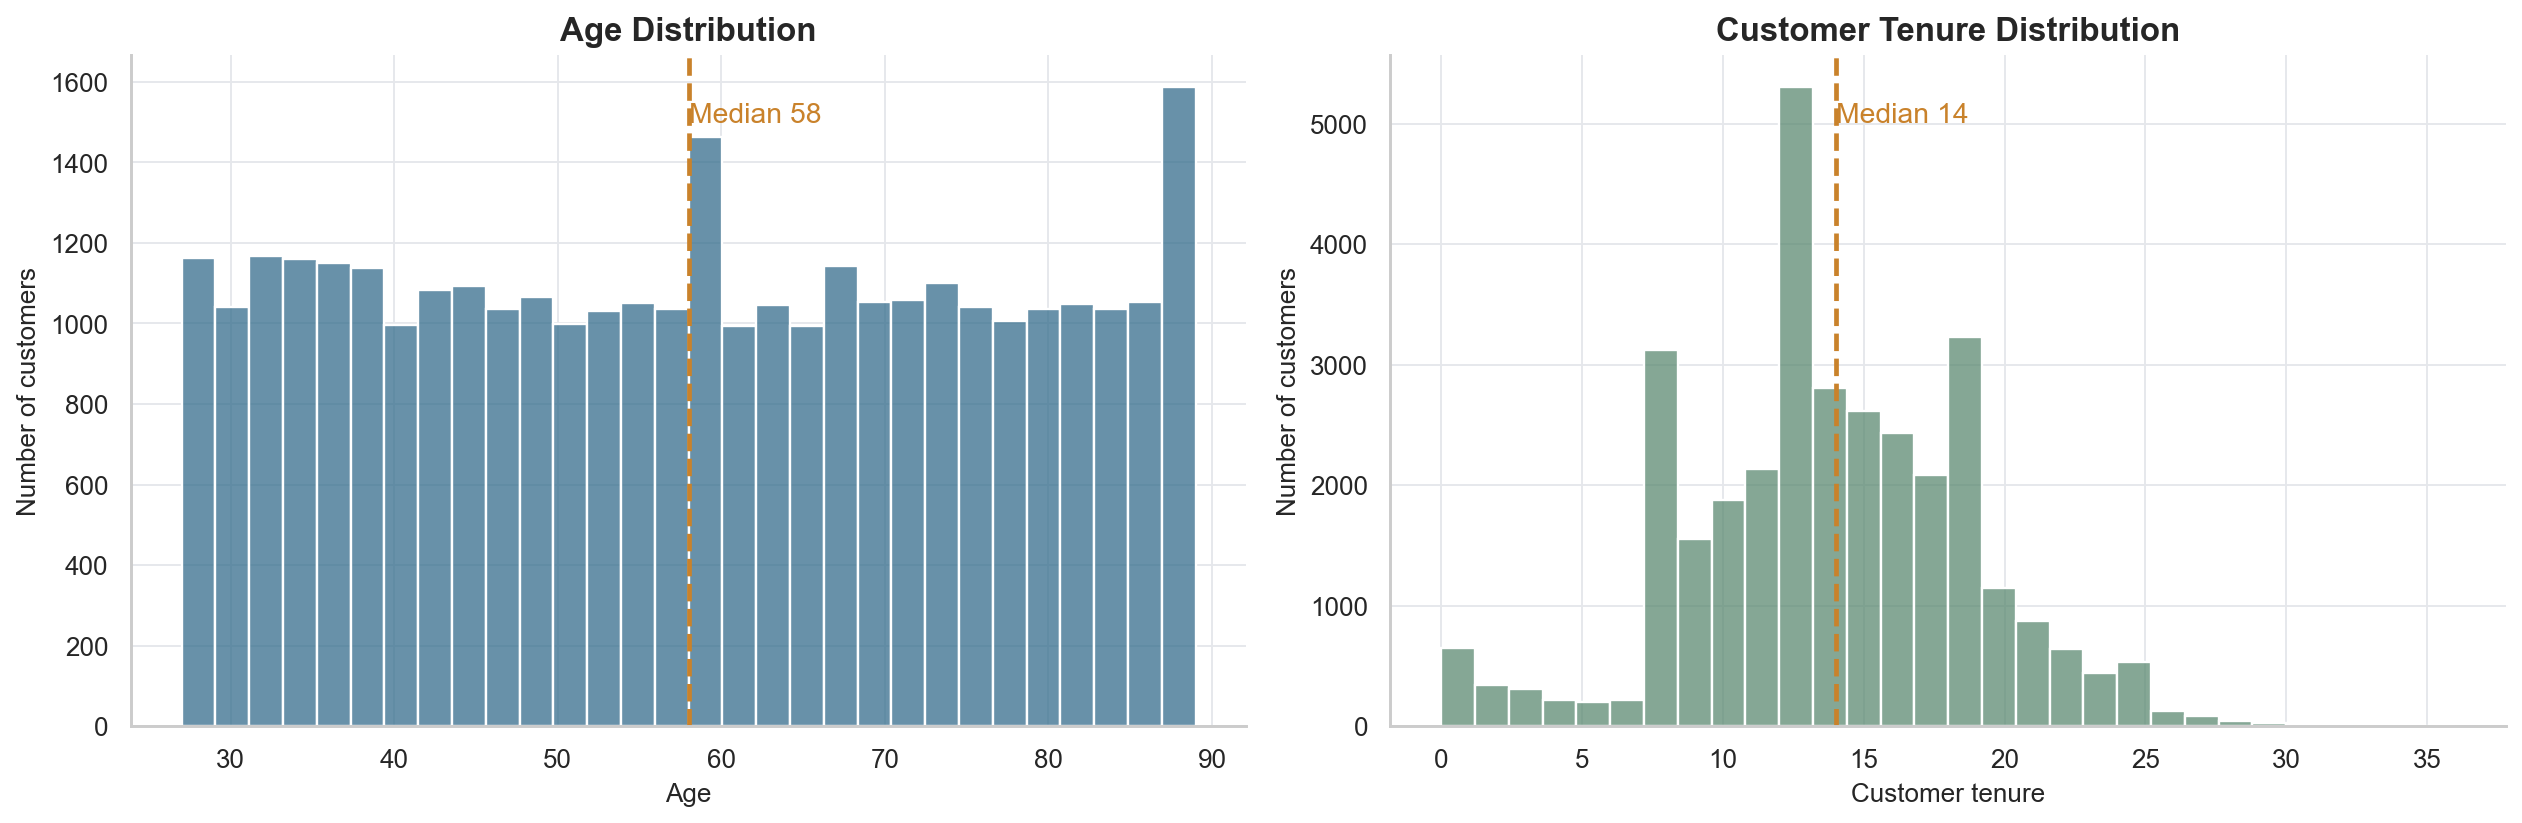

In [6]:
age_median = customer_features["age"].median()
tenure_median = customer_features["customer_tenure"].median()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(customer_features["age"], bins=30, color=PRIMARY, ax=axes[0])
axes[0].axvline(age_median, color=ACCENT, linestyle="--", linewidth=2)
axes[0].text(age_median, axes[0].get_ylim()[1] * 0.9, f"Median {age_median:.0f}", color=ACCENT, ha="left")
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Number of customers")

sns.histplot(customer_features["customer_tenure"], bins=30, color=SECONDARY, ax=axes[1])
axes[1].axvline(tenure_median, color=ACCENT, linestyle="--", linewidth=2)
axes[1].text(tenure_median, axes[1].get_ylim()[1] * 0.9, f"Median {tenure_median:.0f}", color=ACCENT, ha="left")
axes[1].set_title("Customer Tenure Distribution")
axes[1].set_xlabel("Customer tenure")
axes[1].set_ylabel("Number of customers")

display_figure()

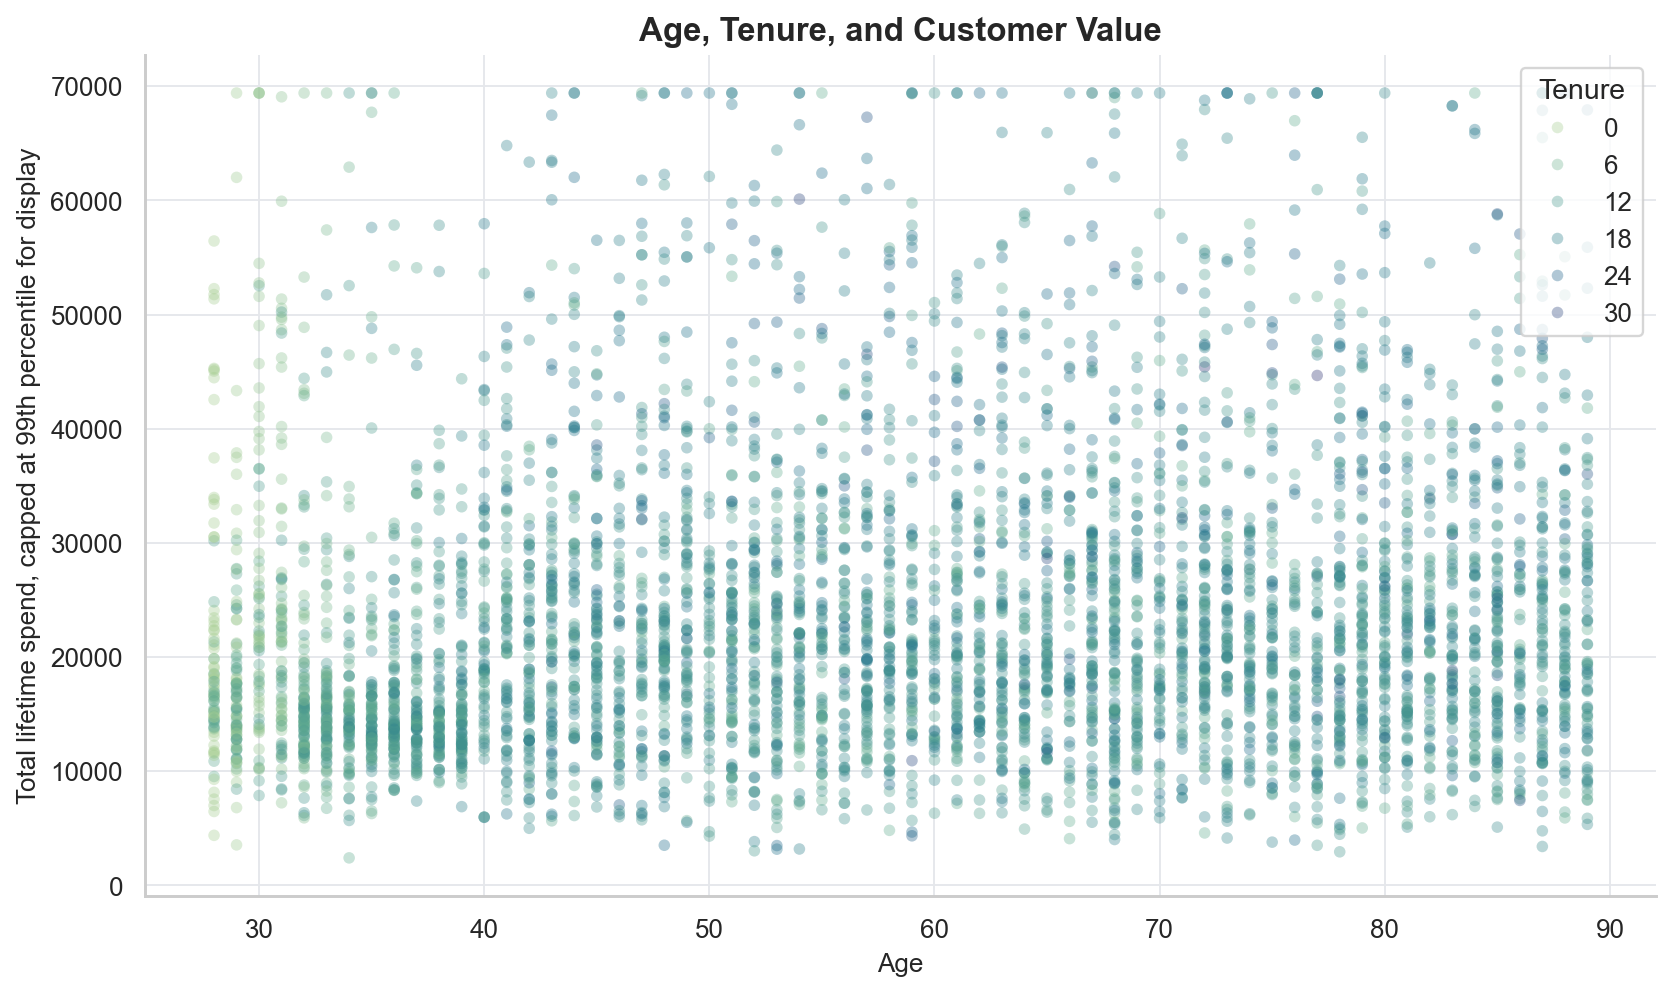

In [7]:
plot_sample = customer_features.sample(n=min(5000, len(customer_features)), random_state=42)
value_cap = customer_features["total_lifetime_spend"].quantile(0.99)

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=plot_sample.assign(
        total_lifetime_spend_display=plot_sample["total_lifetime_spend"].clip(upper=value_cap)
    ),
    x="age",
    y="total_lifetime_spend_display",
    hue="customer_tenure",
    palette="crest",
    alpha=0.35,
    s=24,
    linewidth=0,
    ax=ax,
)
ax.set_title("Age, Tenure, and Customer Value")
ax.set_xlabel("Age")
ax.set_ylabel("Total lifetime spend, capped at 99th percentile for display")
ax.legend(title="Tenure", loc="upper right", frameon=True)

display_figure()


Age and tenure both show broad variation, but the scatter does not point to a single simple age-spend rule. These lifecycle fields are useful context for segmentation when combined with value, preferences, and engagement behaviour.

## Loyalty and Promotions

Compare loyalty-card status and promotion sensitivity against customer value.

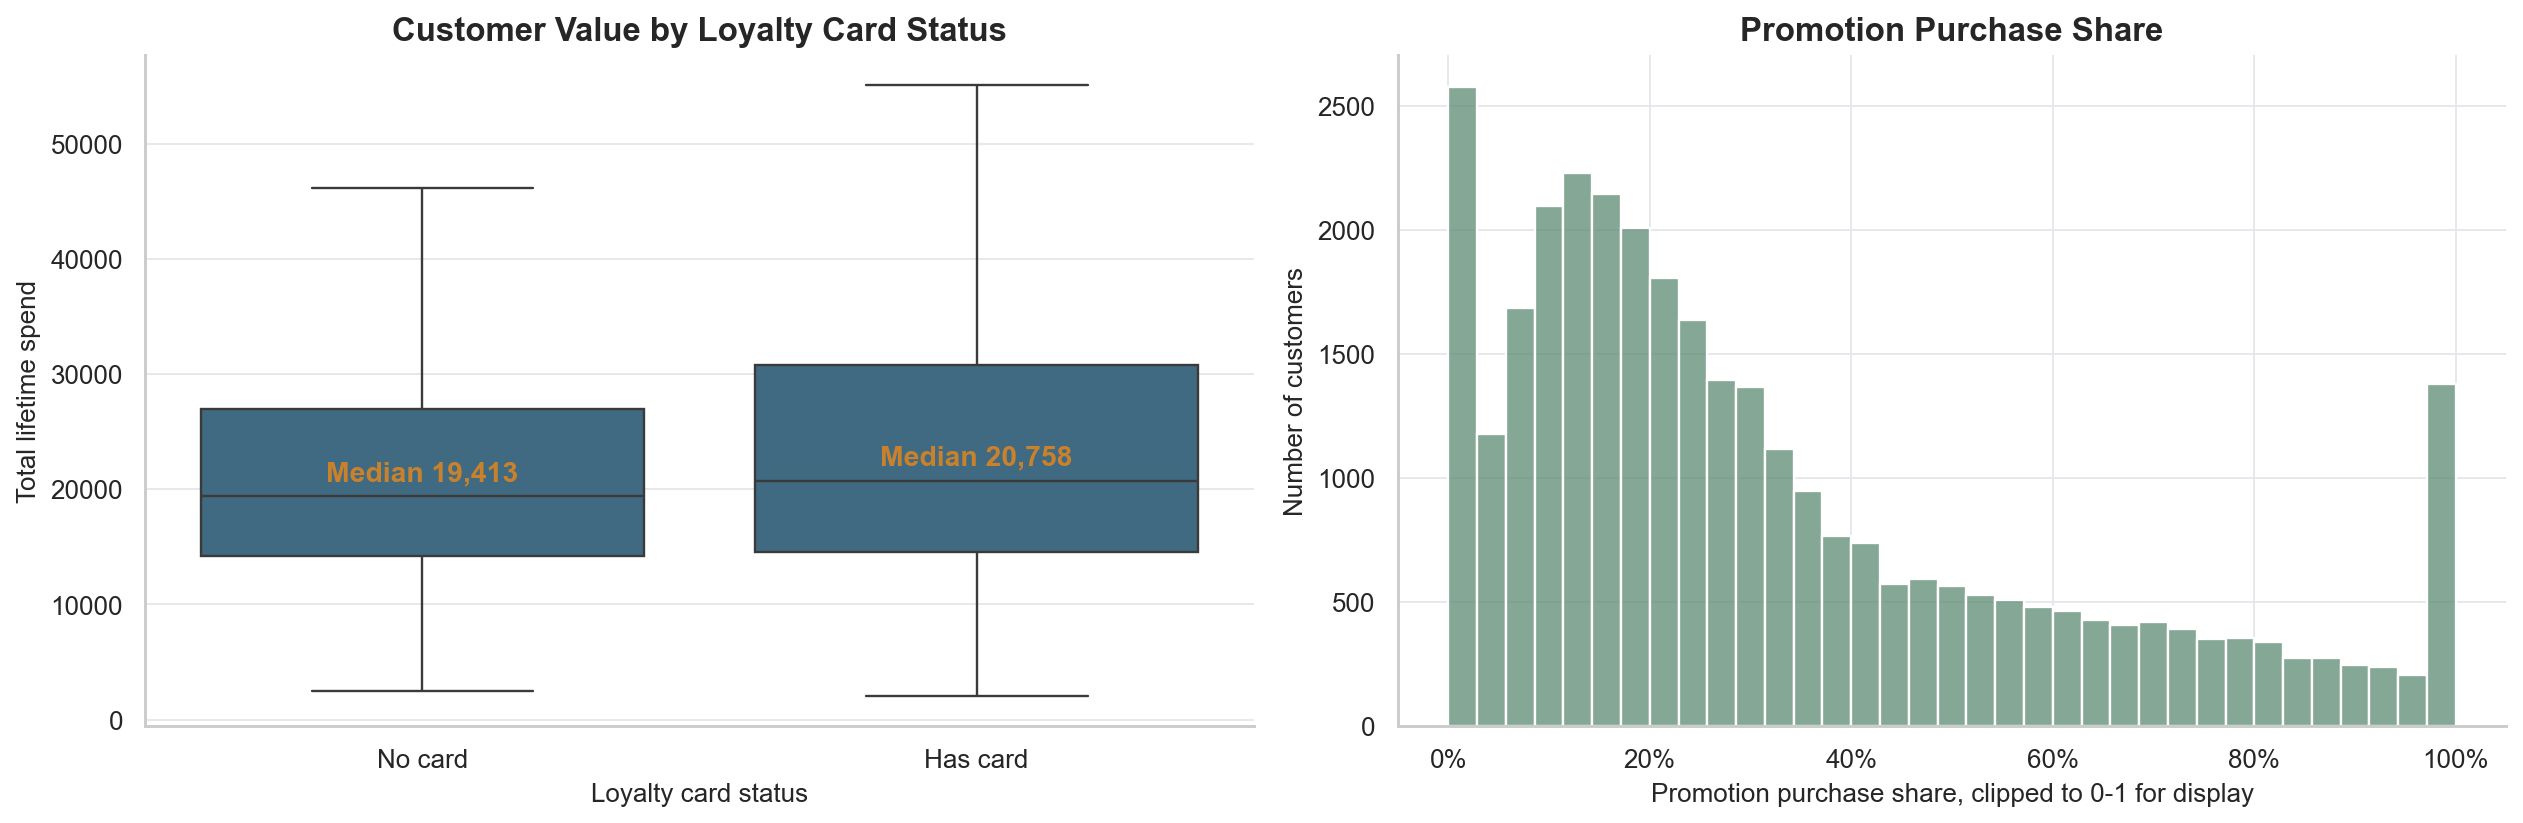

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(
    data=customer_features,
    x="has_loyalty_card",
    y="total_lifetime_spend",
    color=PRIMARY,
    showfliers=False,
    ax=axes[0],
)
axes[0].set_title("Customer Value by Loyalty Card Status")
axes[0].set_xlabel("Loyalty card status")
axes[0].set_ylabel("Total lifetime spend")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["No card", "Has card"])

loyalty_summary = customer_features.groupby("has_loyalty_card")["total_lifetime_spend"].median()
for index, value in loyalty_summary.items():
    axes[0].text(index, value * 1.04, f"Median {value:,.0f}", ha="center", va="bottom", color=ACCENT, fontweight="bold")

promotion_for_plot = customer_features["percentage_of_products_bought_promotion"].clip(lower=0, upper=1)
sns.histplot(promotion_for_plot, bins=35, color=SECONDARY, edgecolor="white", ax=axes[1])
axes[1].set_title("Promotion Purchase Share")
axes[1].set_xlabel("Promotion purchase share, clipped to 0-1 for display")
axes[1].set_ylabel("Number of customers")
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

display_figure()


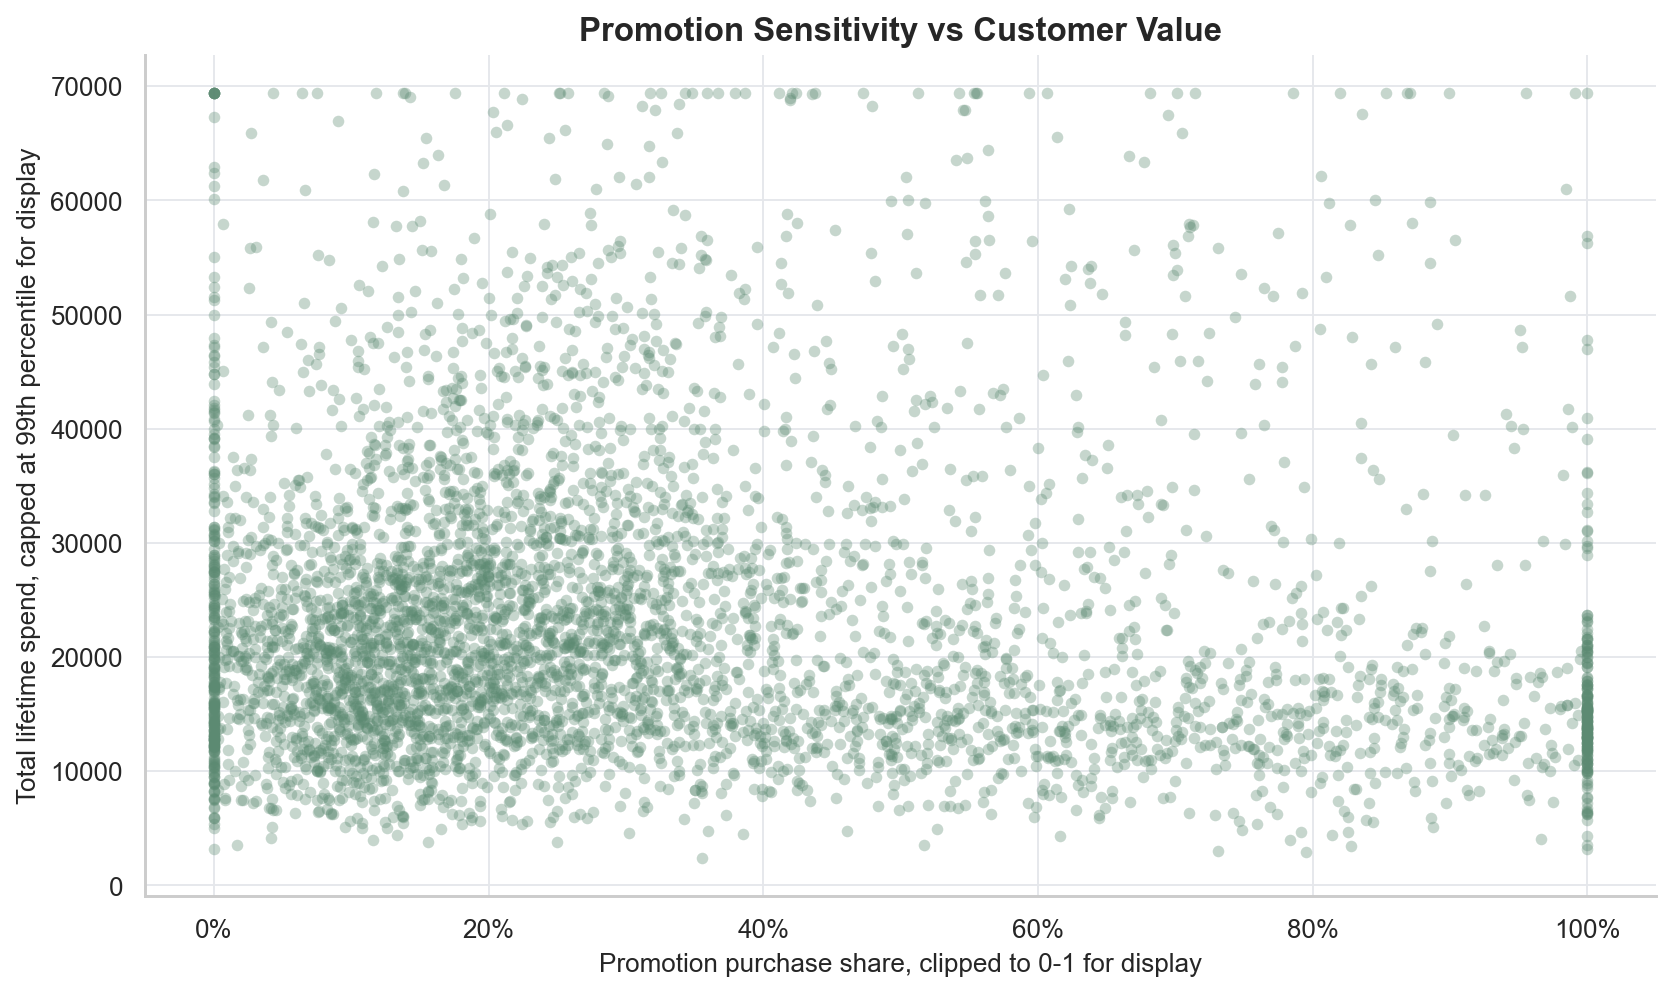

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=plot_sample.assign(
        promotion_share_for_plot=plot_sample["percentage_of_products_bought_promotion"].clip(lower=0, upper=1),
        total_lifetime_spend_display=plot_sample["total_lifetime_spend"].clip(upper=value_cap),
    ),
    x="promotion_share_for_plot",
    y="total_lifetime_spend_display",
    alpha=0.35,
    s=24,
    color=SECONDARY,
    linewidth=0,
    ax=ax,
)
ax.set_title("Promotion Sensitivity vs Customer Value")
ax.set_xlabel("Promotion purchase share, clipped to 0-1 for display")
ax.set_ylabel("Total lifetime spend, capped at 99th percentile for display")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

display_figure()


Loyalty-card status and promotion purchase share are both easy to explain to business stakeholders. Promotion share may separate promotion-sensitive customers, while loyalty status can help profile whether valuable customers are already engaged.

## Spending Preferences

Compare category-level spending mix. Category shares are especially useful because they describe preference rather than only customer size.

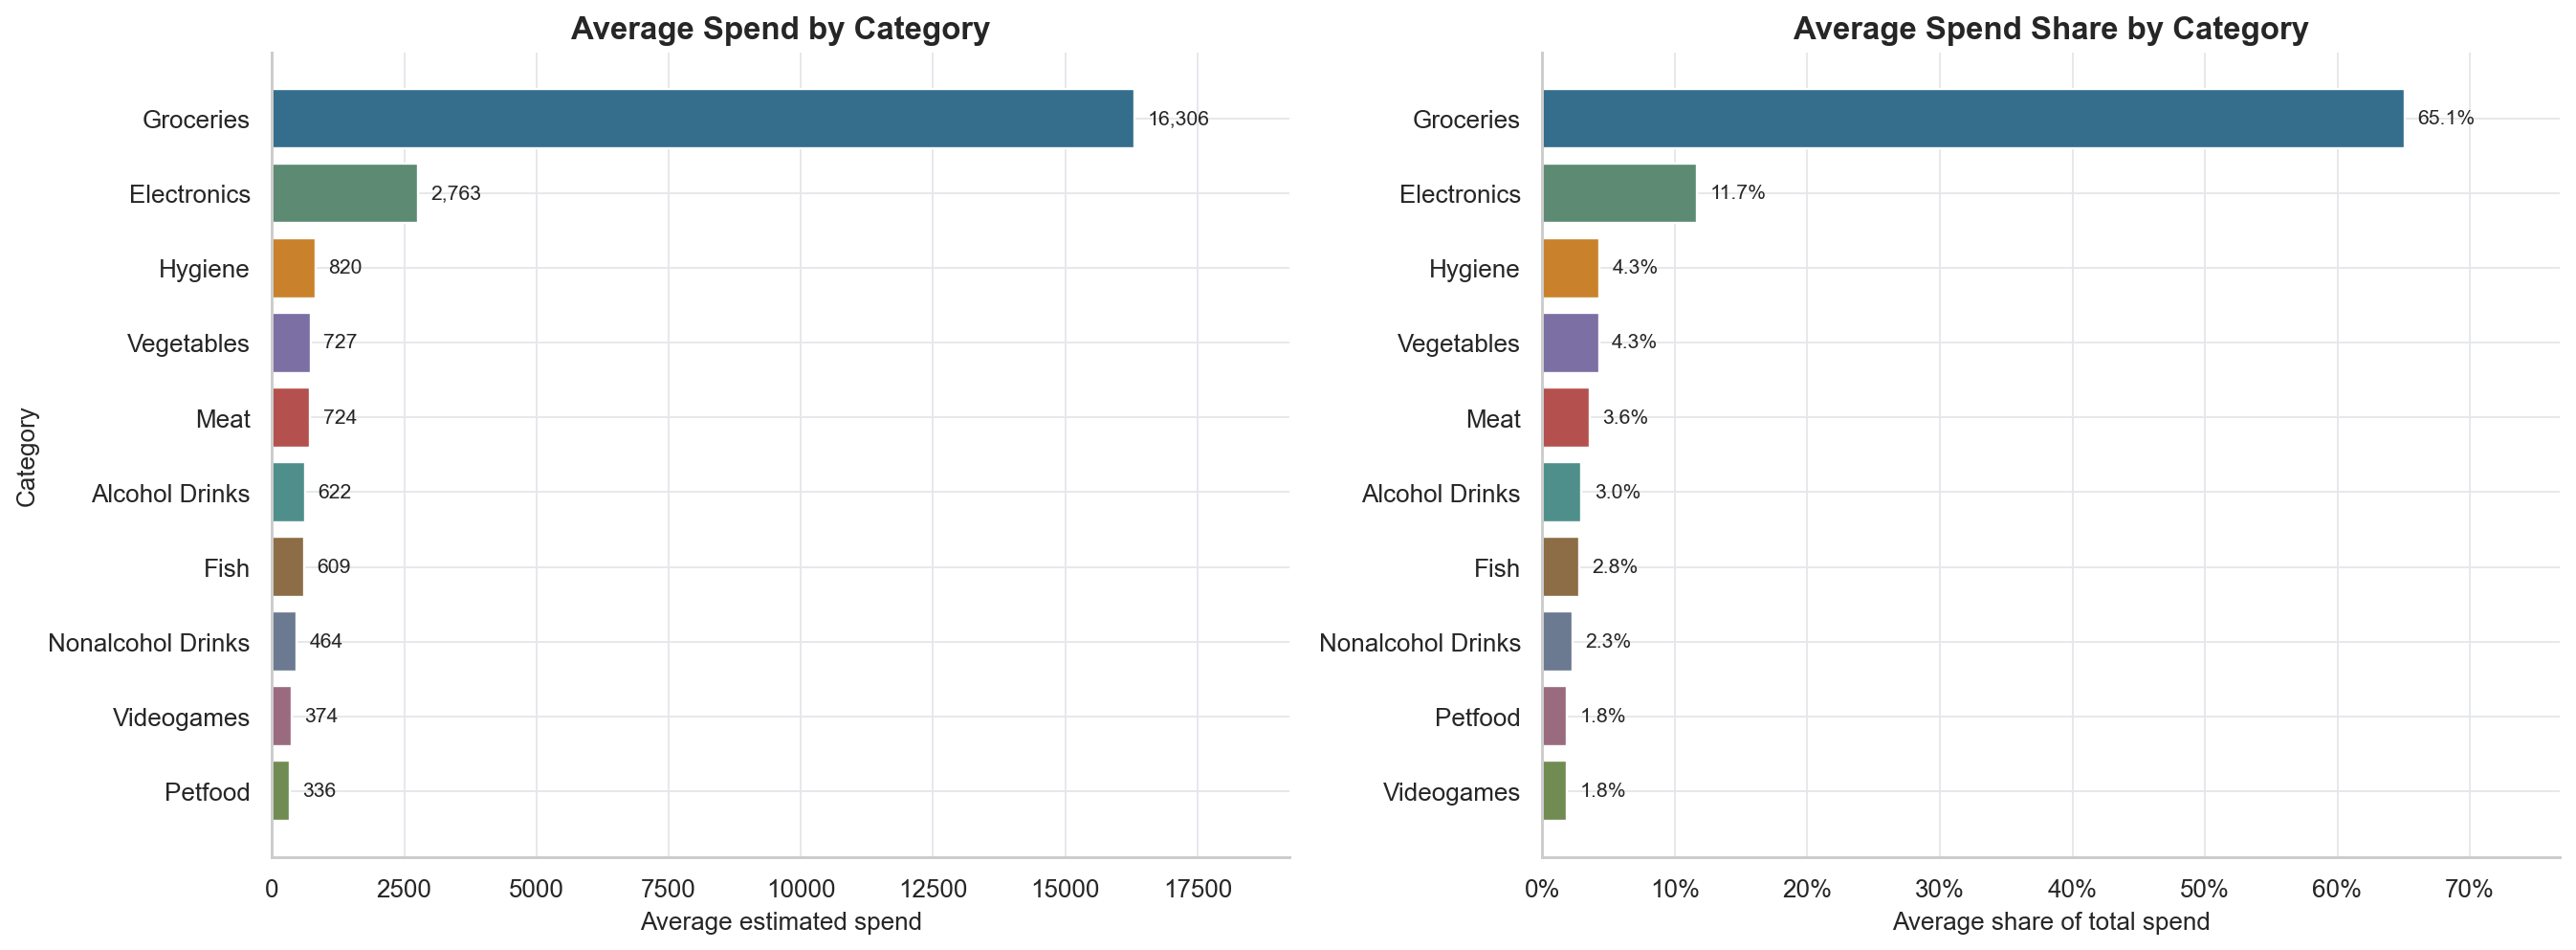

In [10]:
share_columns = [column for column in customer_features.columns if column.startswith("share_")]
category_labels = [clean_label(column) for column in share_columns]
category_name_map = dict(zip(share_columns, category_labels))

avg_spend_by_category = (
    customer_features[share_columns]
    .multiply(customer_features["total_lifetime_spend"], axis=0)
    .mean()
    .rename(index=category_name_map)
    .sort_values(ascending=False)
)

avg_share_by_category = (
    customer_features[share_columns]
    .mean()
    .rename(index=category_name_map)
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(avg_spend_by_category.index, avg_spend_by_category.values, color=CATEGORY_PALETTE)
axes[0].invert_yaxis()
axes[0].set_title("Average Spend by Category")
axes[0].set_xlabel("Average estimated spend")
axes[0].set_ylabel("Category")
axes[0].set_xlim(0, avg_spend_by_category.max() * 1.18)
for index, value in enumerate(avg_spend_by_category.values):
    axes[0].text(value + avg_spend_by_category.max() * 0.015, index, f"{value:,.0f}", va="center", fontsize=9)

axes[1].barh(avg_share_by_category.index, avg_share_by_category.values, color=CATEGORY_PALETTE)
axes[1].invert_yaxis()
axes[1].set_title("Average Spend Share by Category")
axes[1].set_xlabel("Average share of total spend")
axes[1].set_ylabel("")
axes[1].set_xlim(0, avg_share_by_category.max() * 1.18)
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
for index, value in enumerate(avg_share_by_category.values):
    axes[1].text(value + avg_share_by_category.max() * 0.015, index, f"{value:.1%}", va="center", fontsize=9)

display_figure()


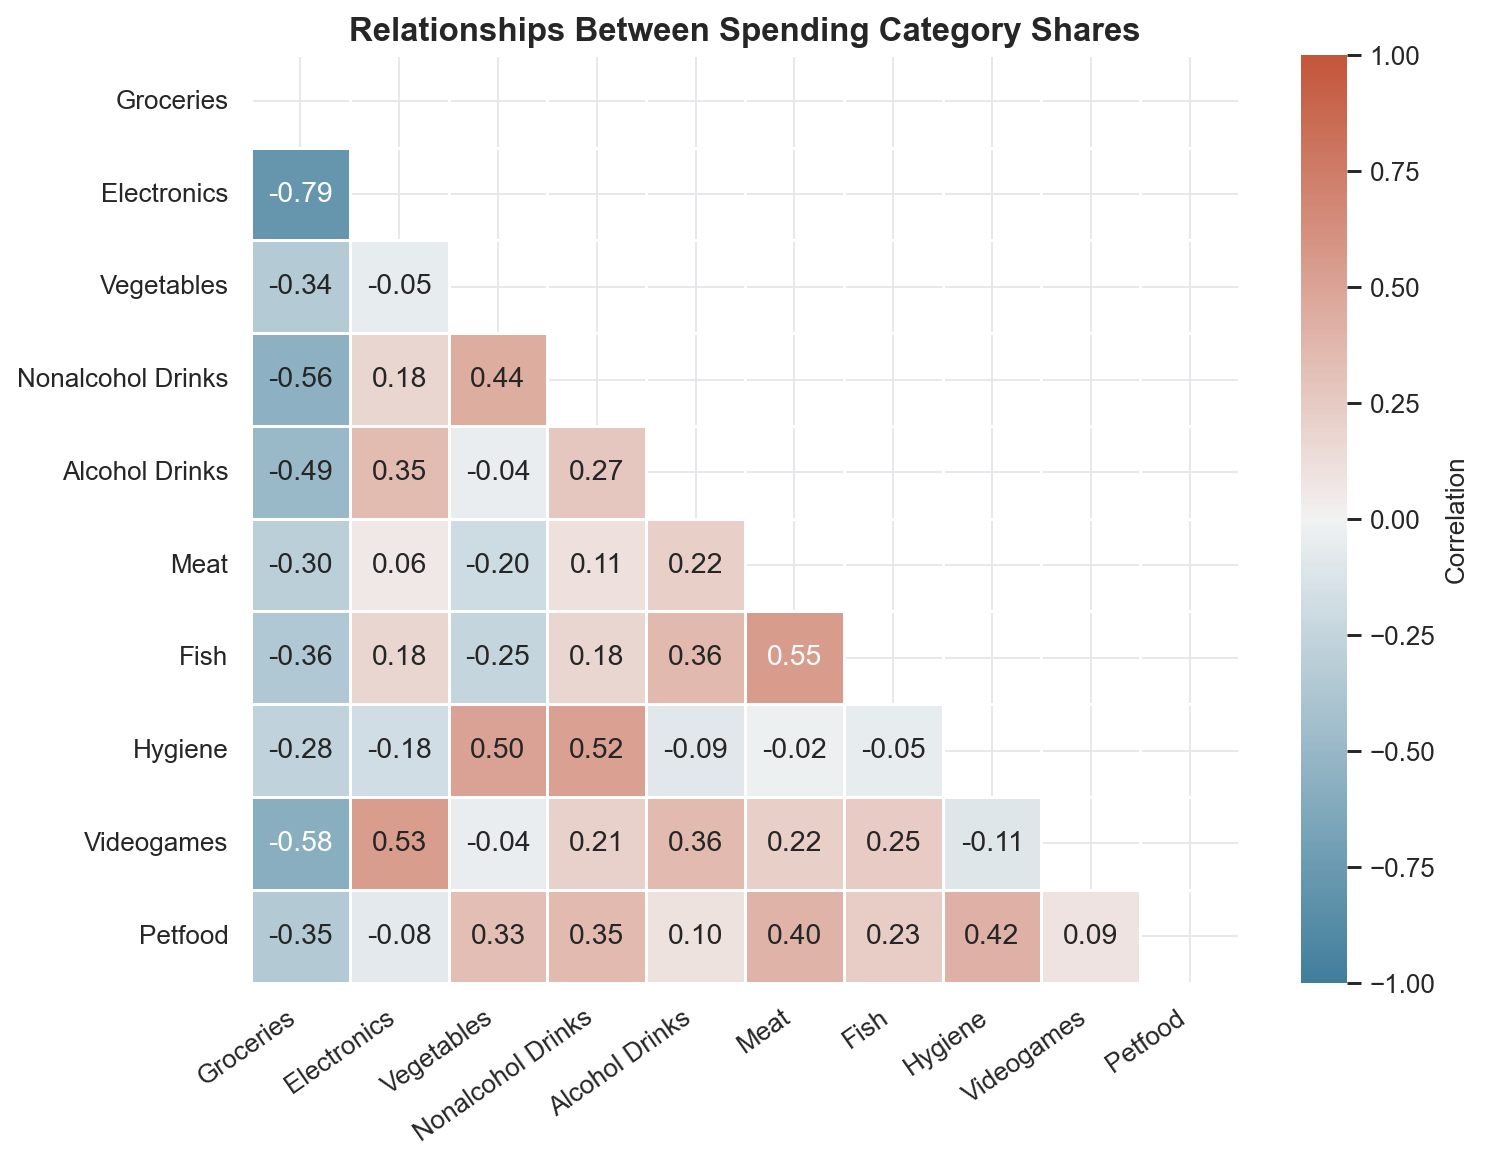

In [11]:
fig, ax = plt.subplots(figsize=(9, 7))
share_corr = customer_features[share_columns].corr()
share_corr.index = category_labels
share_corr.columns = category_labels
mask = np.triu(np.ones_like(share_corr, dtype=bool))
sns.heatmap(
    share_corr,
    mask=mask,
    cmap=sns.diverging_palette(230, 20, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Correlation"},
    ax=ax,
)
ax.set_title("Relationships Between Spending Category Shares")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)

display_figure()


Spending shares provide preference signals that are not the same as total customer value. Groceries dominate average spend, but the smaller categories still help distinguish profile types such as electronics-heavy, fresh-food-oriented, pet-related, or entertainment-oriented customers.

## Basket Behaviour

Basket features add transaction-level behaviour to the customer-level view. They are useful for EDA and later profiling, but not selected for the first K-Means input because basket coverage is incomplete.

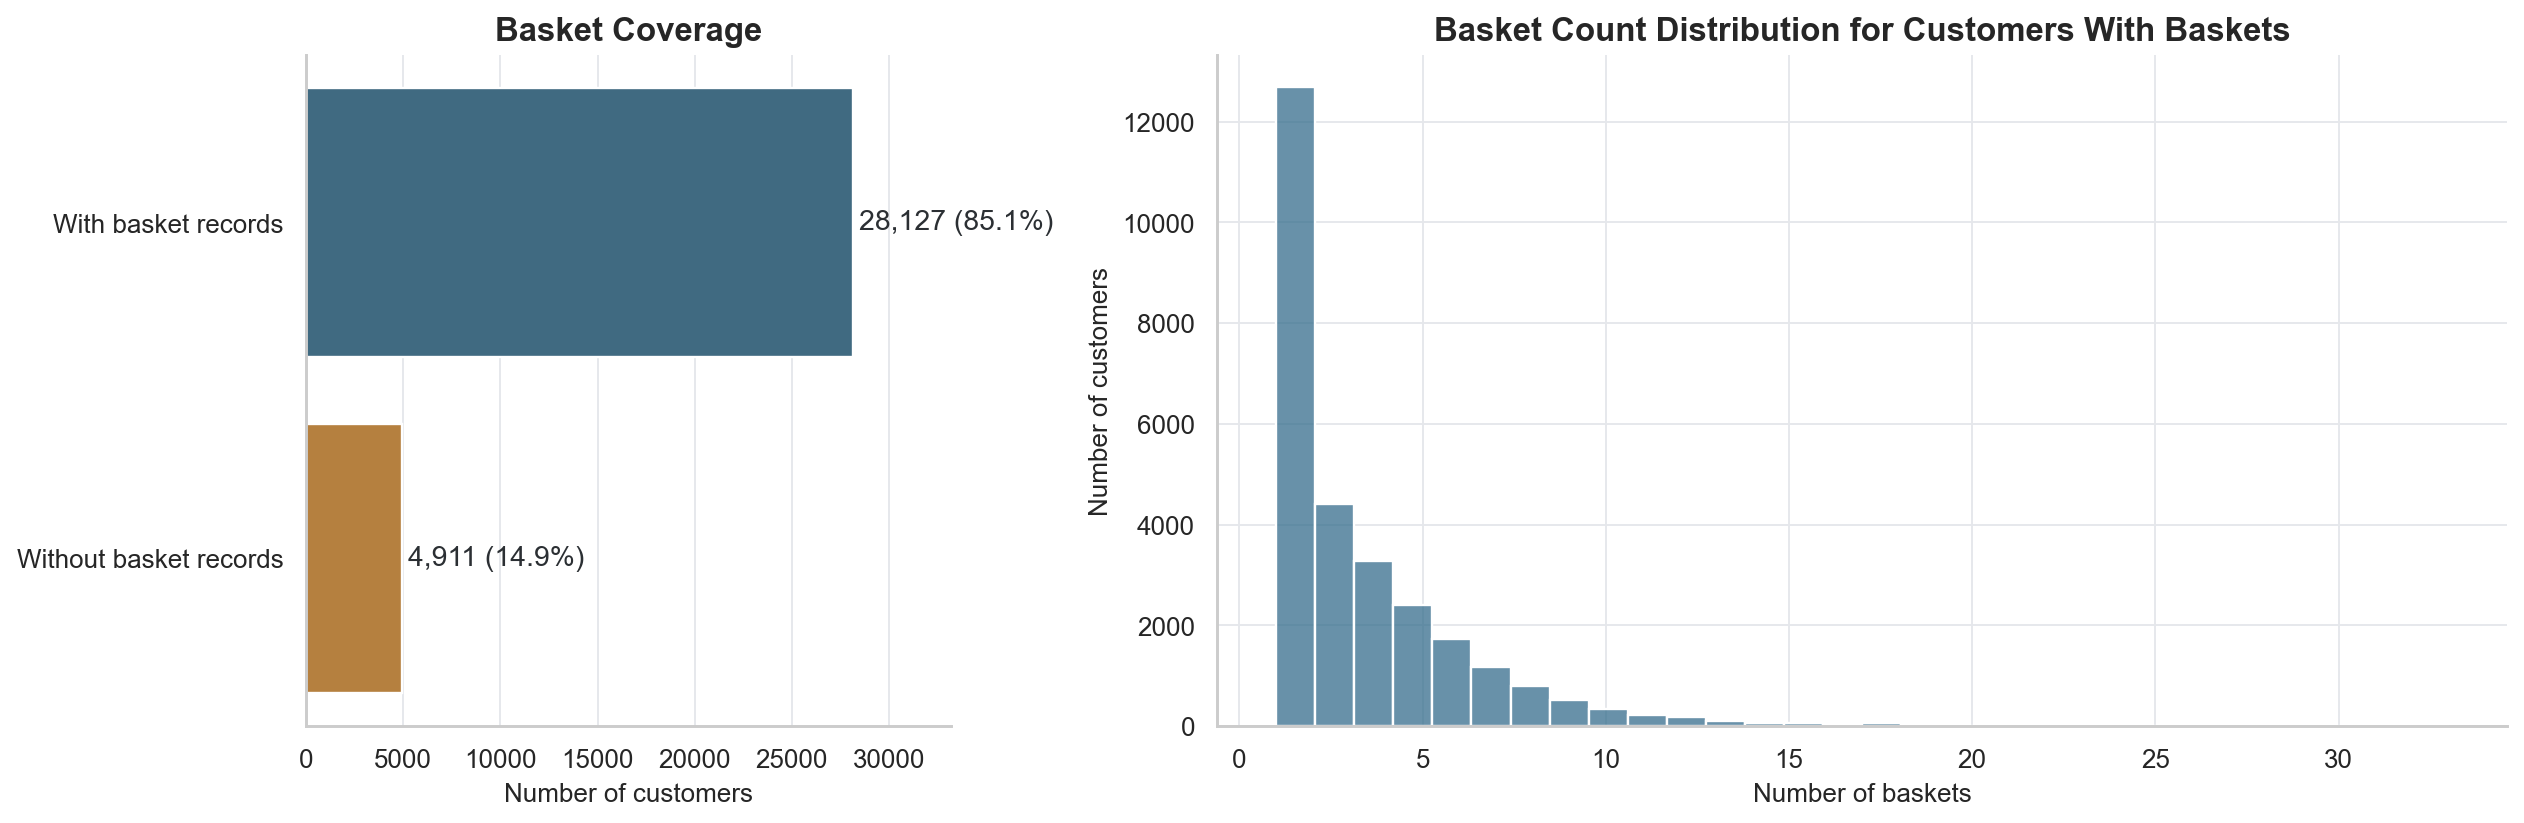

In [12]:
customers_without_baskets = int((customer_features["basket_count"] == 0).sum())
customers_with_baskets = len(customer_features) - customers_without_baskets
basket_coverage = pd.DataFrame(
    {
        "Basket record status": ["With basket records", "Without basket records"],
        "Customers": [customers_with_baskets, customers_without_baskets],
    }
)
basket_coverage["Share"] = basket_coverage["Customers"] / len(customer_features)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [1, 2]})
sns.barplot(
    data=basket_coverage,
    y="Basket record status",
    x="Customers",
    hue="Basket record status",
    palette=[PRIMARY, ACCENT],
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Basket Coverage")
axes[0].set_xlabel("Number of customers")
axes[0].set_ylabel("")
axes[0].set_xlim(0, basket_coverage["Customers"].max() * 1.18)
for index, row in basket_coverage.iterrows():
    axes[0].text(row["Customers"] + 350, index, f"{row['Customers']:,.0f} ({row['Share']:.1%})", va="center", color="#2B2F33")

sns.histplot(
    customer_features.loc[customer_features["basket_count"] > 0, "basket_count"],
    bins=30,
    color=PRIMARY,
    edgecolor="white",
    ax=axes[1],
)
axes[1].set_title("Basket Count Distribution for Customers With Baskets")
axes[1].set_xlabel("Number of baskets")
axes[1].set_ylabel("Number of customers")

display_figure()


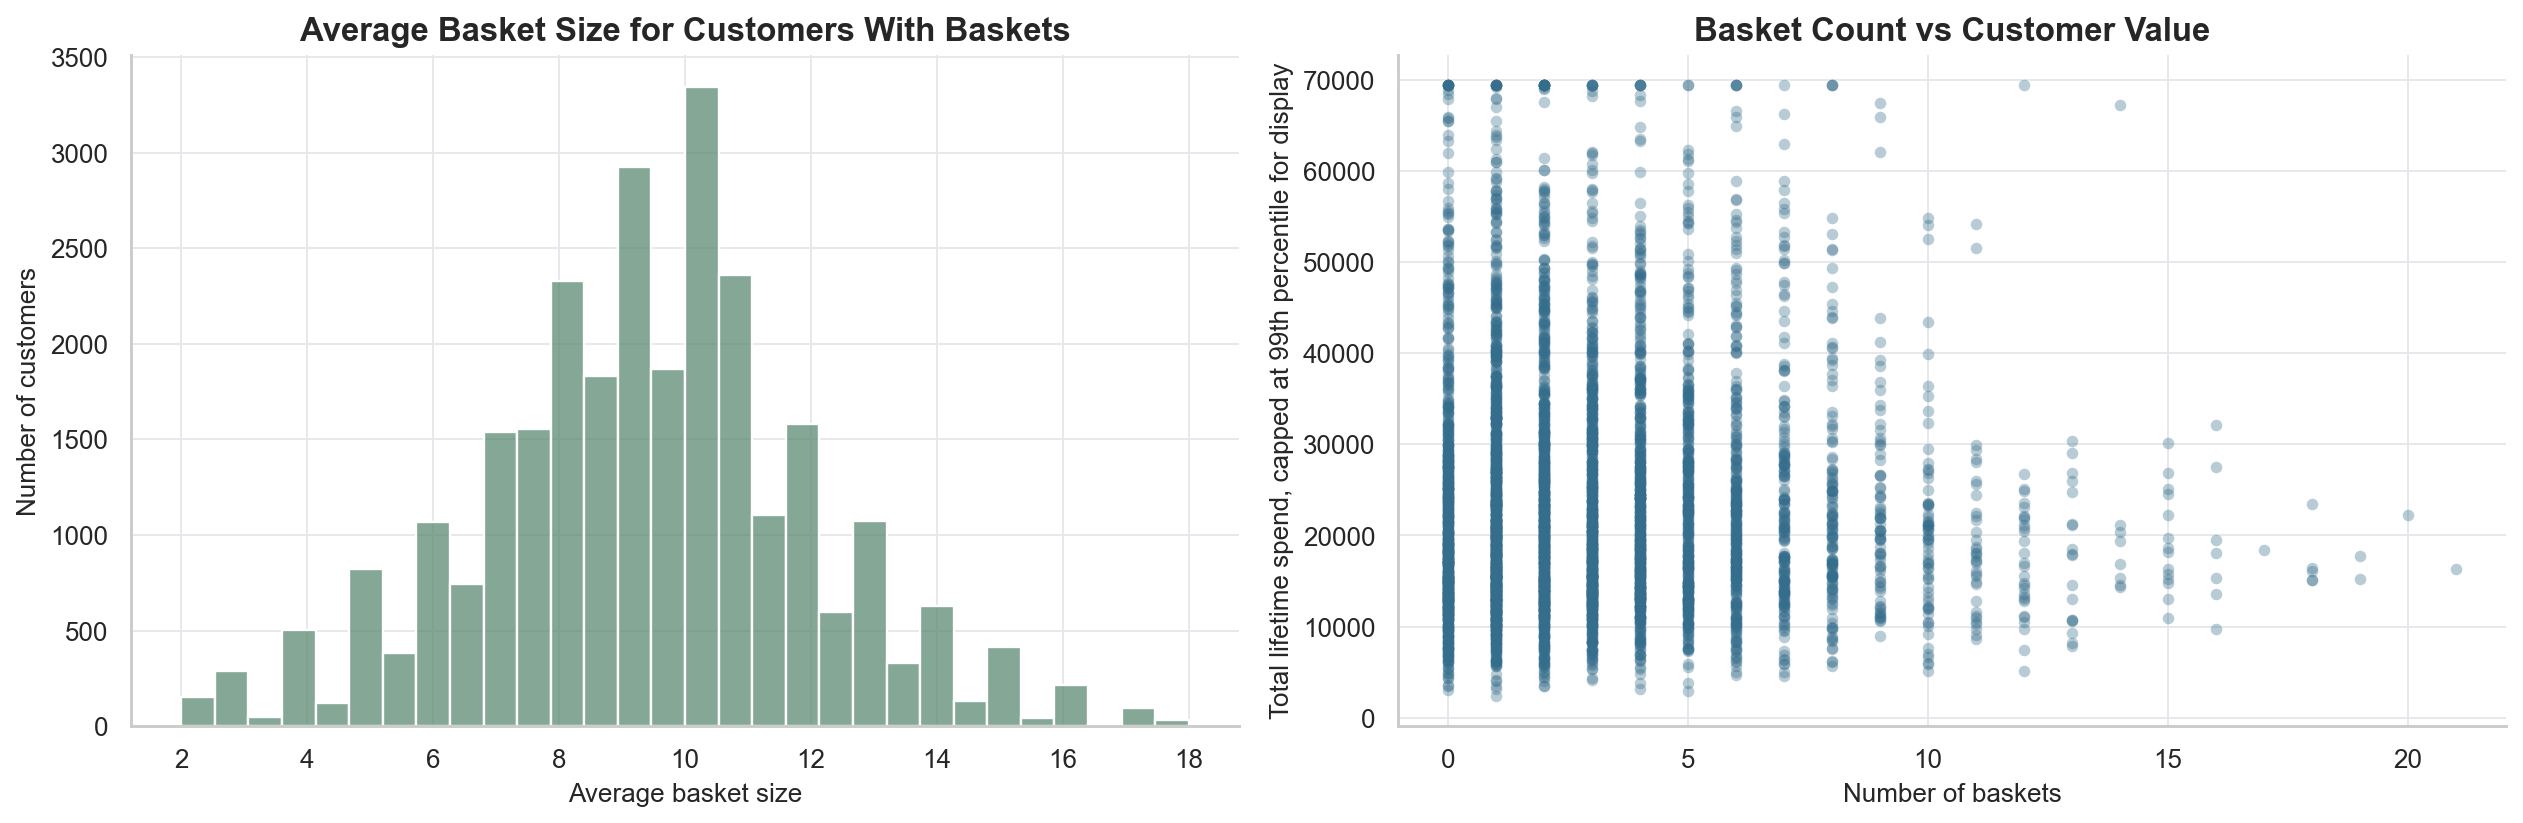

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(
    customer_features.loc[customer_features["avg_basket_size"] > 0, "avg_basket_size"],
    bins=30,
    color=SECONDARY,
    edgecolor="white",
    ax=axes[0],
)
axes[0].set_title("Average Basket Size for Customers With Baskets")
axes[0].set_xlabel("Average basket size")
axes[0].set_ylabel("Number of customers")

sns.scatterplot(
    data=plot_sample.assign(total_lifetime_spend_display=plot_sample["total_lifetime_spend"].clip(upper=value_cap)),
    x="basket_count",
    y="total_lifetime_spend_display",
    alpha=0.35,
    s=24,
    color=PRIMARY,
    linewidth=0,
    ax=axes[1],
)
axes[1].set_title("Basket Count vs Customer Value")
axes[1].set_xlabel("Number of baskets")
axes[1].set_ylabel("Total lifetime spend, capped at 99th percentile for display")

display_figure()


The basket visuals show why these features are useful but risky: 4,911 customers, or about 14.9% of the customer base, have no basket records. Basket features should therefore be used for profiling and promotion design after clusters are created, not for the first baseline clustering input.

## Correlation Overview

Review selected numerical candidates to avoid carrying too many highly related features into the first baseline.

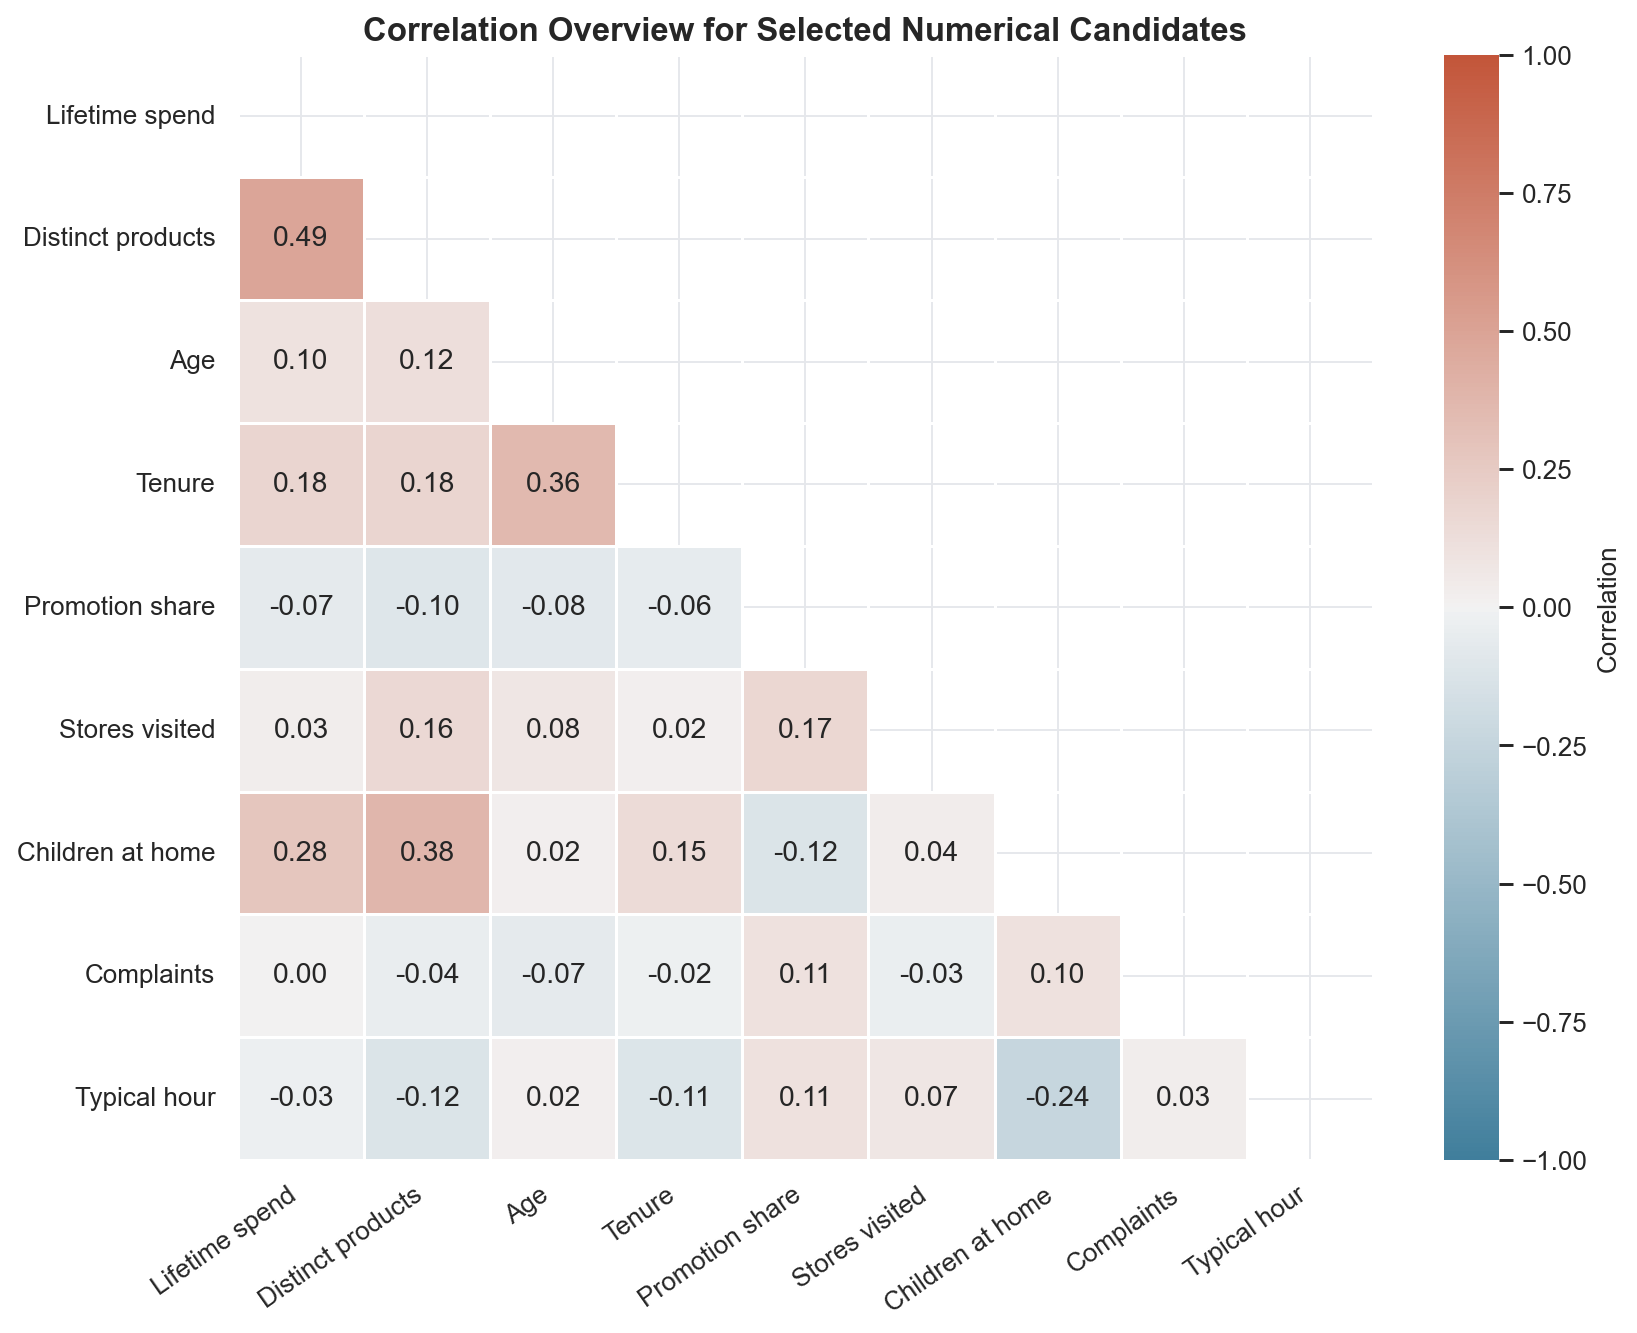

In [14]:
correlation_columns = [
    "total_lifetime_spend",
    "lifetime_total_distinct_products",
    "age",
    "customer_tenure",
    "percentage_of_products_bought_promotion",
    "distinct_stores_visited",
    "total_children_home",
    "number_complaints",
    "typical_hour",
]

correlation_labels = {
    "total_lifetime_spend": "Lifetime spend",
    "lifetime_total_distinct_products": "Distinct products",
    "age": "Age",
    "customer_tenure": "Tenure",
    "percentage_of_products_bought_promotion": "Promotion share",
    "distinct_stores_visited": "Stores visited",
    "total_children_home": "Children at home",
    "number_complaints": "Complaints",
    "typical_hour": "Typical hour",
}

correlation_matrix = customer_features[correlation_columns].corr().rename(
    index=correlation_labels,
    columns=correlation_labels,
)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap=sns.diverging_palette(230, 20, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"},
    ax=ax,
)
ax.set_title("Correlation Overview for Selected Numerical Candidates")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)

display_figure()


The selected numerical fields cover value, lifecycle, promotion behaviour, store activity, household context, complaints, and purchase timing. The strongest relationship is between spend and product variety, which is expected but not so high that both fields say exactly the same thing. Raw transaction year and separate child-count fields remain excluded because more interpretable or less redundant alternatives are available.

# Feature Selection for First Clustering Baseline

Start from `selected_model_features.csv`, then validate the compact, interpretable set of scaled and encoded features for the first clustering baseline. Basket-derived features are intentionally excluded from the selected modelling feature set because `customer_basket` does not cover every customer.

In [15]:
basket_derived_features = [
    "basket_count",
    "avg_basket_size",
    "max_basket_size",
    "min_basket_size",
    "total_items_bought_in_baskets",
    "distinct_products_in_baskets",
    "avg_distinct_products_per_basket",
]

selected_feature_columns = selected_model_features.columns.tolist()
removed_feature_columns = [
    "kids_home",
    "teens_home",
    "year_first_transaction",
    "latitude",
    "longitude",
    "has_children",
    *basket_derived_features,
    "customer_gender_male",
]

basket_features_in_selected = [
    column for column in basket_derived_features
    if column in selected_model_features.columns
]

print(f"Selected columns: {len(selected_feature_columns):,}")
print(f"Removed or profiling-only columns: {len(removed_feature_columns):,}")
print(f"Basket-derived features selected: {basket_features_in_selected}")


Selected columns: 26
Removed columns: 14
Basket-derived features selected: []


## Feature Selection Rationale

The first baseline should be compact, explainable, and safe for distance-based clustering. The selected feature set keeps customer value, lifecycle, promotion sensitivity, shopping variety, spending preferences, household context, gender, and degree-level indicators. It excludes features that are redundant, less interpretable for a first baseline, or better reserved for post-cluster profiling.

In [16]:
removed_feature_reasons = {
    "kids_home": "Replaced by total_children_home",
    "teens_home": "Replaced by total_children_home",
    "year_first_transaction": "Replaced by customer_tenure",
    "latitude": "Excluded from first baseline geography",
    "longitude": "Excluded from first baseline geography",
    "has_children": "Redundant with total_children_home",
    "basket_count": "Profiling-only basket feature",
    "avg_basket_size": "Profiling-only basket feature",
    "max_basket_size": "Profiling-only basket feature",
    "min_basket_size": "Profiling-only basket feature",
    "total_items_bought_in_baskets": "Profiling-only basket feature",
    "distinct_products_in_baskets": "Profiling-only basket feature",
    "avg_distinct_products_per_basket": "Profiling-only basket feature",
    "customer_gender_male": "Redundant with customer_gender_female",
}

removed_features_table = pd.DataFrame(
    {
        "removed_feature": removed_feature_columns,
        "reason": [removed_feature_reasons.get(column, "Review needed") for column in removed_feature_columns],
    }
)
removed_features_table


                 removed_feature                                 reason
                       kids_home        Replaced by total_children_home
                      teens_home        Replaced by total_children_home
          year_first_transaction            Replaced by customer_tenure
                        latitude Excluded from first baseline geography
                       longitude Excluded from first baseline geography
                    has_children     Redundant with total_children_home
                    basket_count          Profiling-only basket feature
                 avg_basket_size          Profiling-only basket feature
                 max_basket_size          Profiling-only basket feature
                 min_basket_size          Profiling-only basket feature
   total_items_bought_in_baskets          Profiling-only basket feature
    distinct_products_in_baskets          Profiling-only basket feature
avg_distinct_products_per_basket          Profiling-only basket 

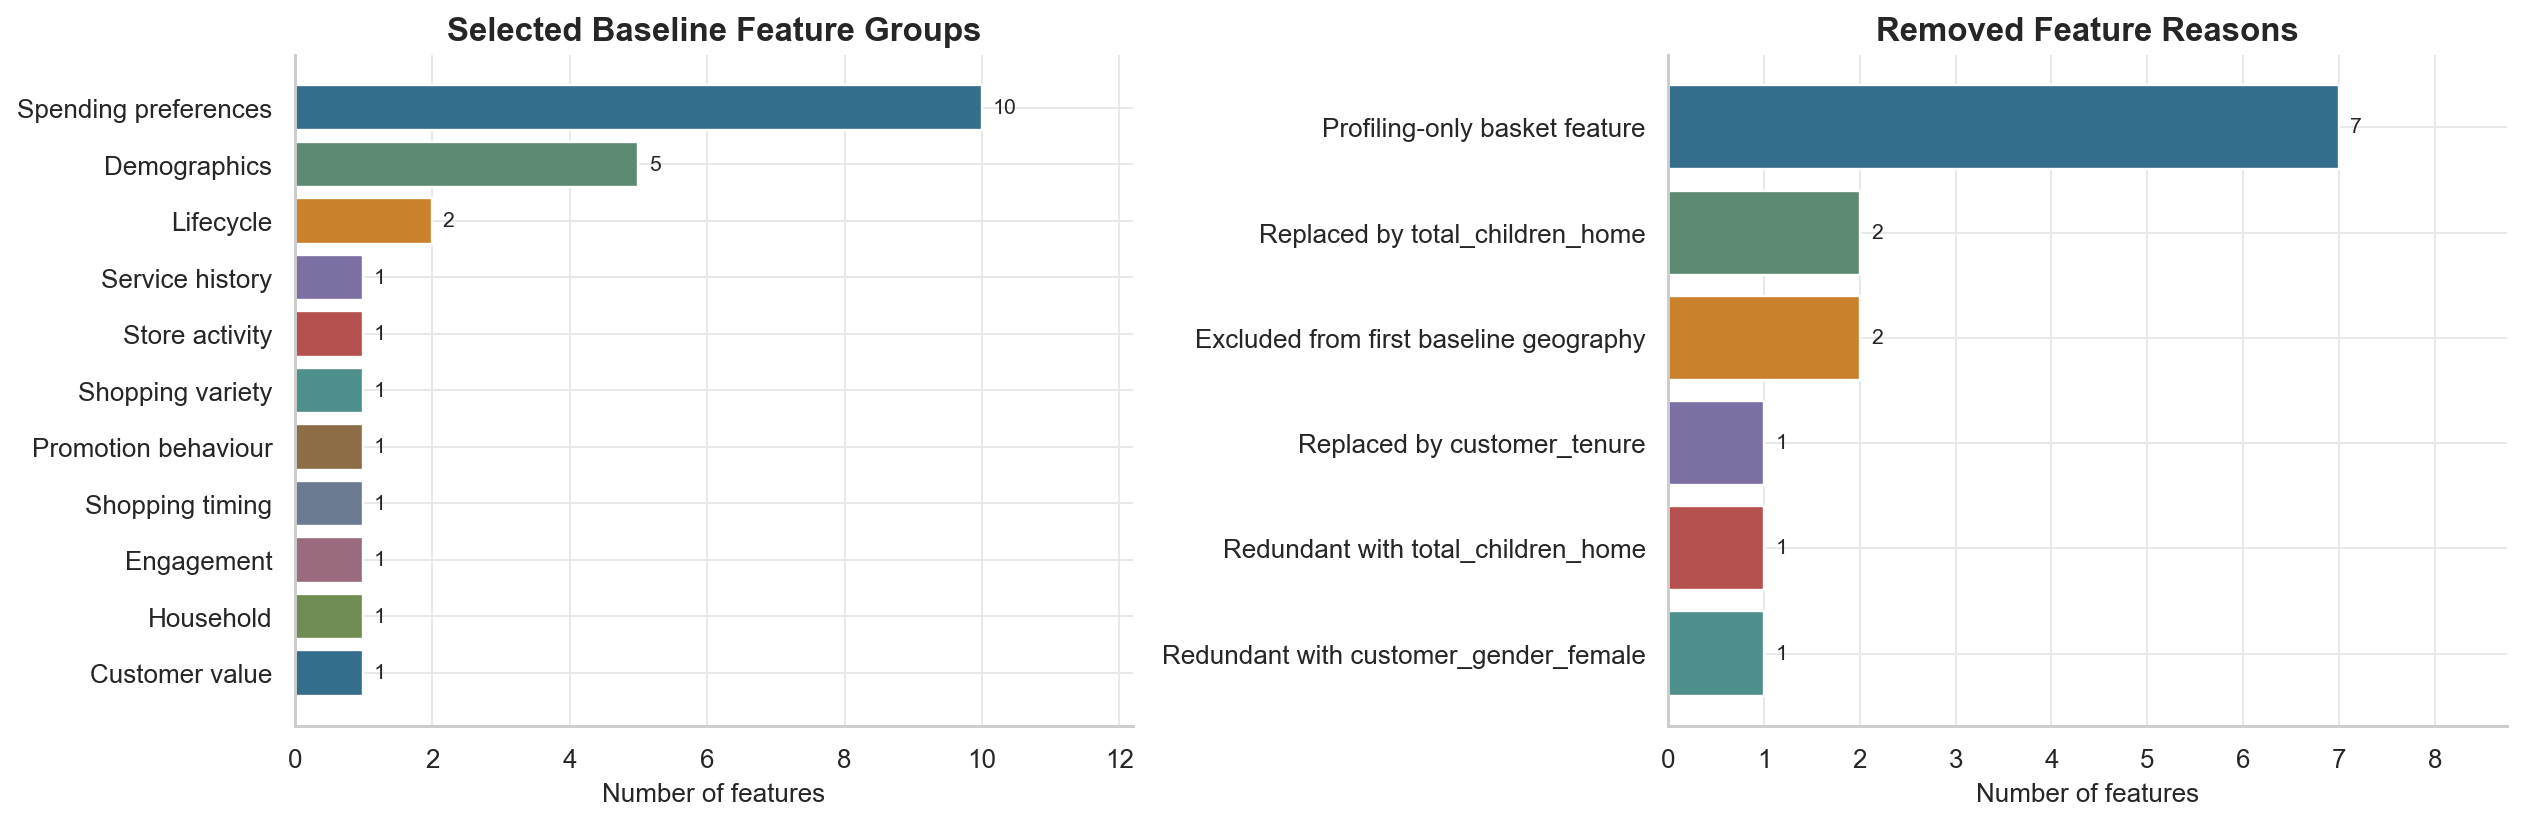

In [17]:
selected_feature_groups = {
    "number_complaints": "Service history",
    "distinct_stores_visited": "Store activity",
    "lifetime_total_distinct_products": "Shopping variety",
    "percentage_of_products_bought_promotion": "Promotion behaviour",
    "typical_hour": "Shopping timing",
    "age": "Lifecycle",
    "customer_tenure": "Lifecycle",
    "has_loyalty_card": "Engagement",
    "total_children_home": "Household",
    "total_lifetime_spend": "Customer value",
    "share_groceries": "Spending preferences",
    "share_electronics": "Spending preferences",
    "share_vegetables": "Spending preferences",
    "share_nonalcohol_drinks": "Spending preferences",
    "share_alcohol_drinks": "Spending preferences",
    "share_meat": "Spending preferences",
    "share_fish": "Spending preferences",
    "share_hygiene": "Spending preferences",
    "share_videogames": "Spending preferences",
    "share_petfood": "Spending preferences",
    "customer_gender_female": "Demographics",
    "degree_level_Bsc": "Demographics",
    "degree_level_Msc": "Demographics",
    "degree_level_Phd": "Demographics",
    "degree_level_Unknown": "Demographics",
}

selected_feature_summary = (
    pd.Series([selected_feature_groups[column] for column in selected_feature_columns if column != "customer_id"])
    .value_counts()
    .rename_axis("Feature group")
    .reset_index(name="Count")
)

removed_reason_summary = (
    removed_features_table["reason"]
    .value_counts()
    .rename_axis("Removal reason")
    .reset_index(name="Count")
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(selected_feature_summary["Feature group"], selected_feature_summary["Count"], color=CATEGORY_PALETTE)
axes[0].invert_yaxis()
axes[0].set_title("Selected Baseline Feature Groups")
axes[0].set_xlabel("Number of features")
axes[0].set_ylabel("")
axes[0].set_xlim(0, selected_feature_summary["Count"].max() * 1.22)
for index, value in enumerate(selected_feature_summary["Count"]):
    axes[0].text(value + 0.15, index, f"{value:.0f}", va="center", fontsize=9)

axes[1].barh(removed_reason_summary["Removal reason"], removed_reason_summary["Count"], color=CATEGORY_PALETTE)
axes[1].invert_yaxis()
axes[1].set_title("Removed Feature Reasons")
axes[1].set_xlabel("Number of features")
axes[1].set_ylabel("")
axes[1].set_xlim(0, removed_reason_summary["Count"].max() * 1.25)
for index, value in enumerate(removed_reason_summary["Count"]):
    axes[1].text(value + 0.12, index, f"{value:.0f}", va="center", fontsize=9)

display_figure()


## Save Selected Features

Save the first-baseline selected feature table. This still does not run clustering.

In [18]:
print("No file saved here; selected_model_features.csv is produced by the preprocessing notebook.")


Saved ../data/processed/selected_model_features.csv


## Final Validation

Validate that the selected baseline table still has one row per customer, no missing values, and no basket-derived features. This file is the input for the first clustering baseline.

In [19]:
validation_summary = pd.DataFrame(
    {
        "check": [
            "row count",
            "matches customer_features_info row count",
            "duplicated customer_id count",
            "missing values count",
            "selected feature count including customer_id",
            "removed/profiling-only feature count",
            "basket-derived features selected",
        ],
        "value": [
            selected_model_features.shape[0],
            selected_model_features.shape[0] == customer_features_info.shape[0],
            selected_model_features["customer_id"].duplicated().sum(),
            selected_model_features.isna().sum().sum(),
            selected_model_features.shape[1],
            len(removed_feature_columns),
            len(basket_features_in_selected),
        ],
    }
)

validation_summary


                                       check value
                                   row count 33038
   matches customer_features_model row count  True
                duplicated customer_id count     0
                        missing values count     0
selected feature count including customer_id    26
                       removed feature count    14
            basket-derived features selected     0

In [20]:
selected_model_features.head()

   customer_id  number_complaints  distinct_stores_visited  lifetime_total_distinct_products  percentage_of_products_bought_promotion  typical_hour       age  customer_tenure  has_loyalty_card  total_children_home  total_lifetime_spend  share_groceries  share_electronics  share_vegetables  share_nonalcohol_drinks  share_alcohol_drinks  share_meat  share_fish  share_hygiene  share_videogames  share_petfood  customer_gender_female  degree_level_Bsc  degree_level_Msc  degree_level_Phd  degree_level_Unknown
0            3           0.076516                -0.099810                          0.378445                                 1.131040     -0.134436  0.048856        -0.931644          0.810886            -0.008470             -0.376002        -0.106198           1.012893         -0.426289                -0.344321             -0.793564   -1.143197   -0.691773      -0.327461         -0.186336       0.163844                       1                 1                 0                 0     

The selected feature table is ready for the first clustering baseline. The next modelling notebook should use this stable customer-level file to compare clustering options and evaluate segment quality without changing the raw data.